# 01. 데이터 점검과 탐색적 분석

**문제.** 카페는 원두를 몇 주~몇 달 앞서 산다. 원두 가격이 오를 것 같거나 크게 흔들릴 것 같으면 미리 사 두고 싶다. 이 프로젝트는 아라비카 커피 선물(ICE, Yahoo `KC=F`)의 **5·20·60거래일 뒤 가격 변화율**과 **가격 변동성**을 예측해 그 판단을 돕는다.

예측 대상은 로그수익률 $y_h = \ln(P_{t+h} / P_t)$ 와, 앞으로 h거래일 동안 일간 수익률의 표준편차(변동성)다.

| 자료 | 내용 | 예측에 쓸 수 있는 시점 |
|---|---|---|
| Yahoo `KC=F`, `COP=X` | 커피 선물 일봉, 콜롬비아 페소/달러 | 당일 마감 후(페소는 다음 날) |
| FRED·ALFRED | 헤알/달러, 미국 기준금리, WTI, 원양 해운 운임(PPI) | 공개일 다음 날 |
| NOAA ONI | 엘니뇨·라니냐 지수(월별) | 3개월 평균의 마지막 달 + 10일 |
| NASA POWER | 브라질 3곳·콜롬비아 3곳의 강수·기온 | 관측일 + 4일 (가정) |

**기간.** 2006–2021년은 **개발 구간**이다. 2012년부터 매년, 그 전까지의 자료로 다시 학습해 다음 해를 평가하는 walk-forward 방식으로 모든 선택을 한다. 2022–2025년은 **보류 구간**으로, 선택을 마친 뒤 한 번만 평가한다(이전 연구에서 결과를 본 적은 있다). 2026년 이후는 최종 모델의 사후 확인 구간이다. 이 노트북의 분석은 개발 구간 안에서만 한다.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf, adfuller, kpss

import common
from coffee.config import HORIZONS, REGIONS
from coffee.features import ALL_FEATURES, FEATURE_GROUPS, build_dataset, trailing_climatology, weather_rolling
from coffee.sources import load_sources

sources = load_sources()
data = build_dataset(sources)
dev = data.loc["2006":"2021"]
print(f"거래일 {len(data):,}일 ({data.index.min():%Y-%m-%d} ~ {data.index.max():%Y-%m-%d}), 피처 {len(ALL_FEATURES)}개")
pd.Series({group: len(columns) for group, columns in FEATURE_GROUPS.items()}, name="피처 수")

거래일 5,474일 (2005-01-03 ~ 2026-10-02), 피처 46개


price       8
macro       5
climate    29
cycle       4
Name: 피처 수, dtype: int64

## 1. 수집 자료 점검

In [2]:
rows = []
for name, frame in sources.items():
    column = "close" if name in ("prices", "fx_cop") else ("value" if name.startswith(("macro", "enso")) else "PRECTOTCORR")
    valid = frame.dropna(subset=[column])
    assumed = int(frame["release_assumed"].sum()) if "release_assumed" in frame else 0
    rows.append({"소스": name, "행 수": len(frame), "시작": valid["date"].min().date(),
                 "마지막 값": valid["date"].max().date(), "결측": int(frame[column].isna().sum()),
                 "공개일 가정 행": assumed})
pd.DataFrame(rows).set_index("소스")

,행 수,시작,마지막 값,결측,공개일 가정 행
소스,,,,,
prices,5467,2005-01-03,2026-10-02,0,0
fx_cop,5652,2005-01-03,2026-10-02,0,0
macro_brl,5670,2005-01-03,2026-09-25,227,2401
macro_rate,7944,2005-01-01,2026-10-01,0,178
macro_oil,5650,2005-01-03,2026-09-29,271,1632
macro_freight,260,2005-01-01,2026-08-01,0,123
enso,259,2005-01-01,2026-07-01,0,0
weather_br_sul_minas,11598,1995-01-01,2026-10-01,1,0
weather_br_cerrado,11598,1995-01-01,2026-10-01,1,0


In [3]:
prices = sources["prices"]
missing_days = data.index[data["close"].isna()]
outside = (prices["close"] > prices["high"]) | (prices["close"] < prices["low"])
print("거래일인데 종가가 없는 날:", len(missing_days), "일 →", [day.strftime("%Y-%m-%d") for day in missing_days][:8])
print(f"종가가 고가·저가 범위를 벗어난 행: {outside.sum()}개 ({outside.mean():.1%})")

거래일인데 종가가 없는 날: 9 일 → ['2005-11-25', '2006-11-24', '2007-11-23', '2007-12-24', '2011-01-03', '2014-09-18', '2016-10-10', '2016-11-11']
종가가 고가·저가 범위를 벗어난 행: 709개 (13.0%)


- 거시 지표는 ALFRED 공개 기록이 지표마다 늦게 시작해(환율 2014년, 유가 2011년, 운임 2015년) 그 전 기간은 공개 지연을 가정했다(표의 '공개일 가정 행'). 환율·금리·유가는 사후 수정이 거의 없어 영향이 작고, 운임 지수는 그 전 기간에 수정된 값을 쓴다는 한계가 있다.
- 종가가 없는 거래일 9일은 주로 미국 공휴일 전후의 단축 거래일이다. 피처는 마지막으로 알려진 종가로 계산하고, 타깃이 없으므로 학습·평가에서는 빠진다.
- 종가가 고가·저가 범위를 벗어난 행이 13%다. 근월물을 이어 붙이는 방식이나 정산가 차이로 보이지만 확인할 방법이 없어 고치지 않고, 모델에는 종가만 쓴다.

## 2. 가격 흐름

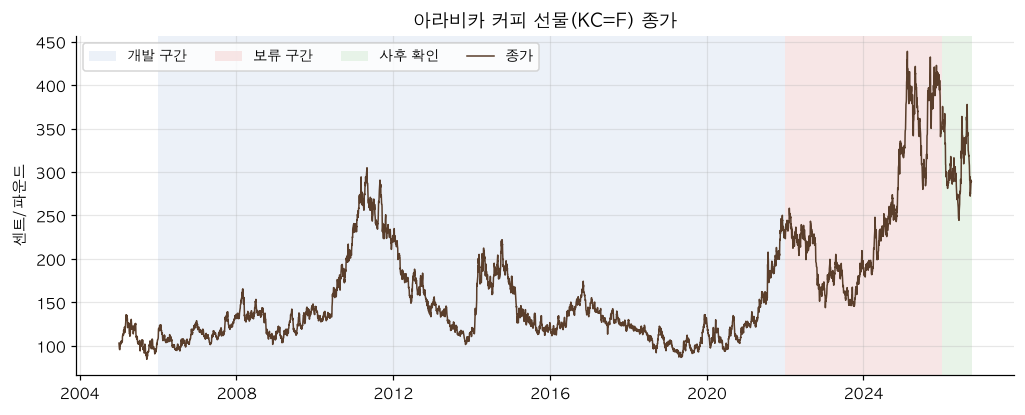

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
common.shade_periods(ax)
ax.plot(data.index, data["close"], lw=1, color="#5a3e2b", label="종가")
ax.set(title="아라비카 커피 선물(KC=F) 종가", ylabel="센트/파운드")
ax.legend(loc="upper left", ncol=4, fontsize=9)
common.save_fig(fig, "price_history.png")
plt.show()

2006–2021년에도 2011년 급등(브라질 작황 부진), 2014년 가뭄 같은 큰 움직임이 있었다. 학습 기간을 2006년부터로 늘린 이유다. 2015년부터 학습하면 박스권만 보고 2022년 이후의 급등·급락을 맞게 된다.

## 3. 예측 대상의 분포와 기본 비율

In [5]:
summary = []
for h in HORIZONS:
    y = dev[f"y_{h}"].dropna()
    summary.append({"지평": f"{h}거래일", "평균": y.mean(), "표준편차": y.std(), "왜도": y.skew(),
                    "첨도": y.kurt(), "상승 비율": (y > 0).mean(), "표본": len(y)})
pd.DataFrame(summary).set_index("지평").round(4)

,평균,표준편차,왜도,첨도,상승 비율,표본
지평,,,,,,
5거래일,0.0009,0.0446,0.2993,1.6143,0.4936,4013
20거래일,0.0032,0.0870,0.4312,1.4444,0.4849,4013
60거래일,0.0108,0.1374,0.6969,1.2471,0.4902,4013


In [6]:
# '항상 오른다'고만 말해도 맞히는 비율. 방향 정확도를 읽을 때 기준이 된다.
base_rates = pd.DataFrame({
    name: [(data.loc[start:end, f"y_{h}"].dropna() > 0).mean() for h in HORIZONS]
    for name, (start, end) in common.PERIODS.items()
}, index=[f"{h}거래일" for h in HORIZONS])
base_rates.round(3)

,개발 구간,보류 구간,사후 확인
5거래일,0.494,0.503,0.435
20거래일,0.485,0.518,0.479
60거래일,0.490,0.578,0.465


개발 구간의 상승 비율은 세 지평 모두 49% 안팎이라 방향을 평가하기에 공평하다. 보류 구간은 60일 상승 비율이 58%로 치우친다. 그래서 방향은 상승과 하락을 각각 맞힌 비율의 평균(균형정확도)이나, 확률이면 기본 비율과 비교한 Brier score로 본다.

## 4. 정상성과 자기상관

가격 수준은 추세가 있어 그대로 회귀하기 어렵다. ADF 검정은 귀무가설이 '단위근이 있다(비정상)', KPSS 검정은 귀무가설이 '정상이다'이다.

In [7]:
def stationarity(series):
    series = series.dropna()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # KPSS는 p값이 표의 범위를 벗어나면 경계값을 돌려주며 경고한다
        return {"ADF p값": adfuller(series, autolag="AIC")[1], "KPSS p값": kpss(series, regression="c", nlags="auto")[1]}

tests = {"로그 가격": stationarity(np.log(dev["close"]))}
tests.update({f"{h}거래일 수익률": stationarity(dev[f"y_{h}"]) for h in HORIZONS})
pd.DataFrame(tests).T.round(4)

,ADF p값,KPSS p값
로그 가격,0.2212,0.01
5거래일 수익률,0.0000,0.10
20거래일 수익률,0.0000,0.10
60거래일 수익률,0.0000,0.10


로그 가격은 단위근을 기각하지 못하고(ADF p=0.22), 수익률은 세 지평 모두 단위근이 기각되며 KPSS로도 정상성이 기각되지 않는다. 가격 수준이 아니라 수익률을 예측하는 이유다.

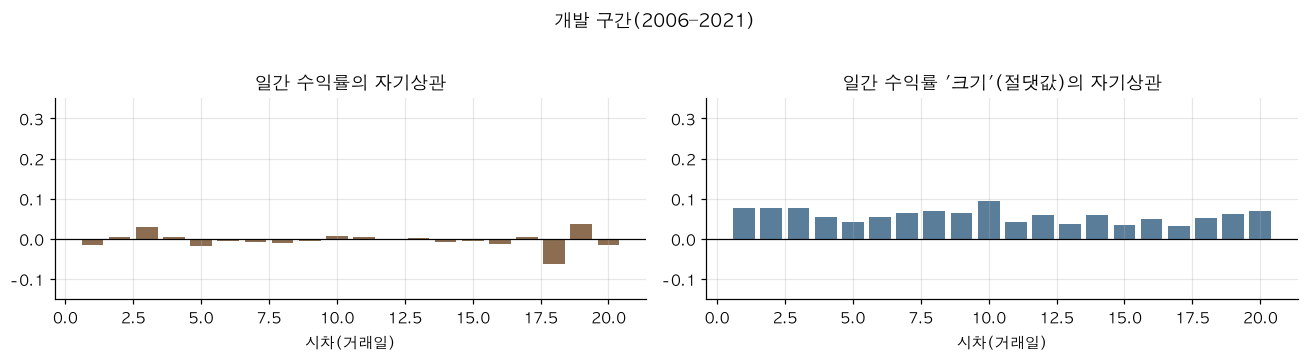

In [8]:
daily = dev["ret_1"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
axes[0].bar(range(1, 21), acf(daily, nlags=20)[1:], color="#8c6d52")
axes[0].set(title="일간 수익률의 자기상관", xlabel="시차(거래일)", ylim=(-0.15, 0.35))
axes[1].bar(range(1, 21), acf(daily.abs(), nlags=20)[1:], color="#5a7d9a")
axes[1].set(title="일간 수익률 '크기'(절댓값)의 자기상관", xlabel="시차(거래일)", ylim=(-0.15, 0.35))
for ax in axes:
    ax.axhline(0, color="black", lw=0.8)
fig.suptitle("개발 구간(2006–2021)", y=1.02)
fig.tight_layout()
common.save_fig(fig, "volatility_clustering.png")
plt.show()

일간 수익률 자체는 자기상관이 거의 없다. 어제의 방향으로 내일의 방향을 맞히기 어렵다는 뜻이다. 반면 수익률의 **크기**는 뚜렷하게 이어진다. 크게 움직인 날 뒤에는 크게 움직이는 날이 온다(변동성 군집). 가격의 방향보다 **변동성**이 더 예측하기 쉬울 것이라는 근거이고, 04에서 변동성 예측을 따로 다루는 이유다.

## 5. 기상 편차의 기준: 고정 평년값과 직전 10년 평년값

In [9]:
# 고정 평년값(1995–2004 같은 달 평균) 기준과 직전 10년 같은 달 평균 기준으로 90일 강수 편차를 비교한다.
rows = {}
for region in REGIONS:
    rolled = weather_rolling(sources[f"weather_{region['id']}"].set_index("date"))
    fixed = rolled.loc["1995":"2004"].groupby(rolled.loc["1995":"2004"].index.month)
    fixed_spi = (rolled["rain90"] - fixed["rain90"].mean().reindex(rolled.index.month).to_numpy()) \
        / fixed["rain90"].std().reindex(rolled.index.month).to_numpy()
    rows[(region["id"], "고정")] = fixed_spi.loc["2006":"2021"].groupby(fixed_spi.loc["2006":"2021"].index.year).mean()
    rows[(region["id"], "직전 10년")] = dev[f"{region['id']}_spi90"].groupby(dev.index.year).mean()
spi = pd.DataFrame(rows)
print("연도별 평균 표준화 90일 강수 (음수 = 평년보다 건조)")
spi[[("co_caldas", "고정"), ("co_caldas", "직전 10년"), ("br_cerrado", "고정"), ("br_cerrado", "직전 10년")]].round(2)

연도별 평균 표준화 90일 강수 (음수 = 평년보다 건조)


co_caldas        br_cerrado       
            고정 직전 10년         고정 직전 10년
date                                   
2006     -1.26  -1.06       0.23   0.25
2007     -1.87  -1.47      -0.98  -0.97
2008     -1.99  -1.32      -0.21  -0.14
2009     -1.15  -0.28       0.59   0.79
2010     -1.01   0.07      -0.77  -0.74
2011     -0.59   1.28      -0.27  -0.13
2012     -0.47   1.41      -0.37   0.00
2013     -0.41   1.40      -0.43  -0.23
2014     -0.64   0.78      -1.19  -0.95
2015     -1.52  -0.77      -0.80  -0.45
2016     -1.52  -0.65      -0.98  -0.53
2017     -0.90   0.34      -0.99  -0.43
2018     -1.02   0.01      -0.22   0.32
2019     -1.16  -0.42      -0.42   0.18
2020     -1.47  -1.01      -0.90  -0.22
2021     -1.85  -1.69      -1.43  -0.88

In [10]:
print("2006–2021 전체 평균:", spi.mean().unstack().round(2).to_dict())

2006–2021 전체 평균: {'고정': {'br_alta_mogiana': -0.44, 'br_cerrado': -0.57, 'br_sul_minas': -0.54, 'co_antioquia': -1.24, 'co_caldas': -1.18, 'co_huila': -0.07}, '직전 10년': {'br_alta_mogiana': -0.28, 'br_cerrado': -0.26, 'br_sul_minas': -0.22, 'co_antioquia': -0.39, 'co_caldas': -0.21, 'co_huila': 0.1}}


처음에는 1981–2004년(이후 1995–2004년) 같은 달 평균을 평년값으로 고정했다. 그러자 콜롬비아 칼다스·안티오키아는 2006–2021년 평균이 −1.2로, 거의 모든 해가 '가뭄'으로 나왔다. 기후가 실제로 건조해졌을 수도 있고 위성 기반 자료의 수준이 바뀌었을 수도 있다. 어느 쪽이든 이런 피처에는 연도 추세가 섞여, 모델이 우연한 수준 관계를 배우게 된다. 그래서 기준을 **직전 10년 같은 달 평균**으로 바꿨다. 각 해에 그 이전 10년만 쓰므로 미래 정보가 섞이지 않는다. 바꾼 뒤에는 평균이 0 근처(−0.2~0.1)이고, 2010–2013년 습윤(라니냐)이나 2015–2016년 건조(엘니뇨) 같은 실제 기후 사건이 부호로 드러난다.

## 6. 피처와 예측 대상의 관계

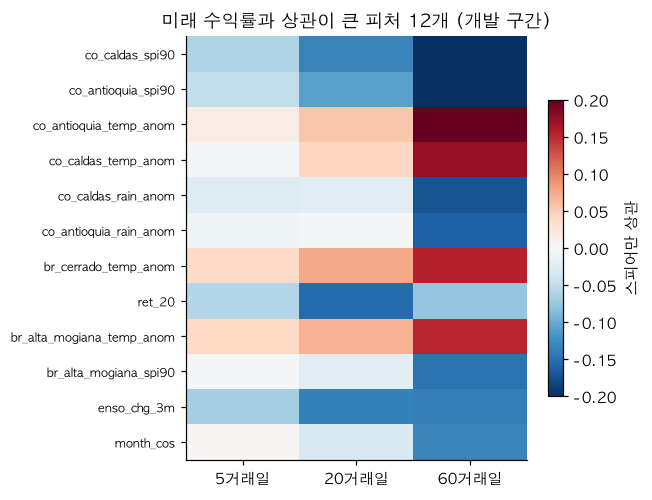

,5거래일,20거래일,60거래일
co_caldas_spi90,-0.061,-0.134,-0.246
co_antioquia_spi90,-0.049,-0.109,-0.238
co_antioquia_temp_anom,0.015,0.056,0.211
co_caldas_temp_anom,-0.002,0.041,0.174
co_caldas_rain_anom,-0.026,-0.023,-0.172
co_antioquia_rain_anom,-0.008,-0.002,-0.164
br_cerrado_temp_anom,0.038,0.076,0.155
ret_20,-0.059,-0.153,-0.077
br_alta_mogiana_temp_anom,0.039,0.070,0.152
br_alta_mogiana_spi90,-0.003,-0.021,-0.147


In [11]:
targets = [f"y_{h}" for h in HORIZONS]
corr = dev[ALL_FEATURES + targets].corr(method="spearman").loc[ALL_FEATURES, targets]
corr.columns = [f"{h}거래일" for h in HORIZONS]
top = corr.abs().max(axis=1).sort_values(ascending=False).head(12).index

fig, ax = plt.subplots(figsize=(5, 5))
image = ax.imshow(corr.loc[top].to_numpy(), cmap="RdBu_r", vmin=-0.2, vmax=0.2, aspect="auto")
ax.set_xticks(range(3), corr.columns)
ax.set_yticks(range(len(top)), top, fontsize=8)
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.7, label="스피어만 상관")
ax.set_title("미래 수익률과 상관이 큰 피처 12개 (개발 구간)")
common.save_fig(fig, "feature_correlation.png")
plt.show()
corr.loc[top].round(3)

상관은 모두 작다(0.25 이하). 가장 큰 관계는 콜롬비아의 90일 강수 편차와 60일 수익률(−0.25)이다. 산지가 건조할수록 석 달 뒤 가격이 오르는 경향으로, 공급 감소라는 해석과 맞는다. 5일에서는 거의 0이다. 기상처럼 천천히 움직이는 지표는 긴 지평에서만 의미가 있을 수 있다. 상관만으로 피처를 고르지 않고 02에서 walk-forward 성능으로 판단한다.

### 사례: 2021년 7월 브라질 서리

NASA POWER는 약 50km 격자의 평균이라 서리 당일에도 최저기온이 3℃(남미나스)였다. 그래서 '0℃ 미만' 같은 서리 기준 대신 **7일 중 가장 낮은 최저기온이 직전 10년 같은 달보다 얼마나 낮은지**(한파 편차)를 쓴다.

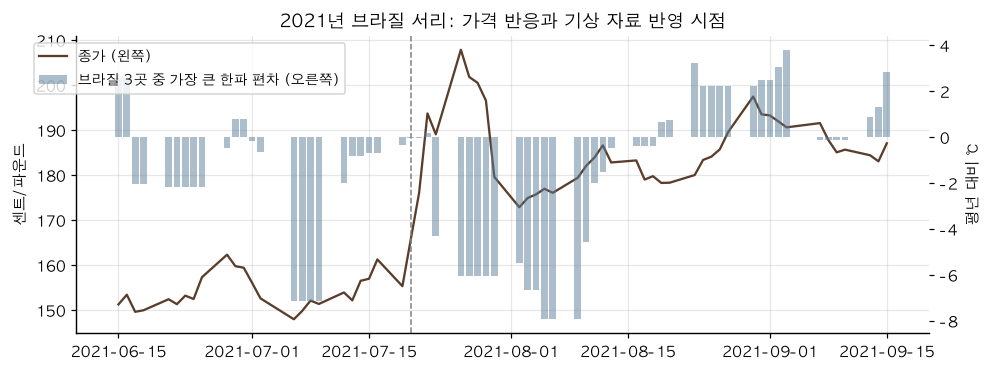

,close,br_sul_minas_cold_anom,br_cerrado_cold_anom,br_alta_mogiana_cold_anom
date,,,,
2021-07-19,155.25,-0.24,-0.04,-0.36
2021-07-20,165.65,0.09,-0.04,0.29
2021-07-21,176.00,0.10,-0.04,0.29
2021-07-22,193.65,0.15,0.25,1.48
2021-07-23,189.00,-2.38,-0.18,-4.32
2021-07-26,207.80,-6.08,-4.78,-5.17
2021-07-27,201.75,-6.08,-4.78,-5.17


In [12]:
window = data.loc["2021-06-15":"2021-09-15"]
cold_columns = [column for column in FEATURE_GROUPS["climate"] if column.endswith("_cold_anom")]

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(window.index, window["close"], color="#5a3e2b", label="종가 (왼쪽)")
ax.set_ylabel("센트/파운드")
twin = ax.twinx()
twin.bar(window.index, window[cold_columns].min(axis=1), color="#5a7d9a", alpha=0.5, label="브라질 3곳 중 가장 큰 한파 편차 (오른쪽)")
twin.set_ylabel("평년 대비 ℃")
twin.grid(False)
ax.axvline(pd.Timestamp("2021-07-20"), color="gray", ls="--", lw=1)
ax.set_title("2021년 브라질 서리: 가격 반응과 기상 자료 반영 시점")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.88), fontsize=9)
common.save_fig(fig, "frost_2021.png")
plt.show()
window.loc["2021-07-19":"2021-07-27", ["close"] + cold_columns].round(2)

가격은 서리 직후인 7월 21~22일에 이미 크게 올랐다. 기상 자료는 관측일 + 4일 규칙 때문에 7월 23일부터 반영되기 시작해 26일에야 크게 나타난다. 기상 자료만으로는 이런 충격을 앞서 잡기 어렵다. 단기 이슈를 뉴스로 보완해 보려 한 이유다(05).

### 해거리 주기

아라비카는 많이 열린 해 다음 해에 덜 여는 경향이 있다. 브라질 작물년도(7월 시작)별로 1년 가격 변화를 짝수·홀수 해로 나눠 본다.

In [13]:
july = data["close"].dropna().resample("YS-JUL").first()
yearly = pd.DataFrame({"작물년도 시작": july.index.year, "1년 로그 변화": np.log(july.shift(-1) / july).to_numpy()}).dropna()
yearly["짝수 해 시작"] = yearly["작물년도 시작"] % 2 == 0
dev_years = yearly[(yearly["작물년도 시작"] >= 2006) & (yearly["작물년도 시작"] <= 2020)]
print(dev_years.groupby("짝수 해 시작")["1년 로그 변화"].agg(["mean", "count"]).round(3))

          mean  count
짝수 해 시작              
False    0.075      7
True    -0.012      8


홀수 해에 시작한 작물년도의 1년 가격 변화가 평균 +7.5%, 짝수 해는 −1.2%였다. 각 7~8개년뿐이라 우연일 수 있지만, 해거리 주기를 피처(24개월 주기의 sin·cos)로 넣어 볼 근거는 된다.

## 7. 학부 원본 노트북과 달라진 점

| 학부 원본 | 문제 | 이번 설계 |
|---|---|---|
| 테스트 입력에 스케일링을 적용하지 않음 | 학습과 다른 단위의 입력으로 평가 | 스케일러를 학습 구간에서 fit하고 모델과 함께 저장 |
| 테스트 손실로 학습률·epoch 조정 | 평가 구간이 모델 선택에 쓰임(누수) | 선택은 개발 구간의 walk-forward로만, epoch는 고정 |
| 방향 손실을 `sign()`으로 계산 | 기울기가 0이라 학습에 영향 없음 | 방향은 별도 확률 모델과 평가 지표로 다룸 |
| 기준선 없음 | 모델이 의미 있는지 판단 불가 | Naive·Momentum·기본 비율·직전 변동성과 비교 |
| 병합 전 결측을 앞 값으로 채움, 기상 공개 지연 없음 | 미래에 알 수 없는 값이 섞임 | 지표마다 이용 가능 시점을 정해 as-of로 결합 |
| 80/20 한 번 분할 | 한 구간 결과에 좌우됨 | 10개 연도 fold + 보류 구간 |

## 정리

- 학습 기간을 2006년부터로 늘려 2011년 급등, 2014년 가뭄 같은 여러 국면을 담았다.
- 수익률은 방향의 자기상관이 거의 없지만 크기(변동성)는 이어진다. 방향보다 변동성이 예측하기 쉬울 것이다.
- 기상 편차는 직전 10년 평년값을 기준으로 바꿔 연도 추세가 섞이지 않게 했다.
- 피처와 수익률의 상관은 모두 작다. 기후는 긴 지평(60일)에서만 약한 관계가 보인다.
- 서리 지수는 격자 자료의 한계로 한파 편차로 바꿨다. 기상 자료는 공개 지연 때문에 단기 충격에 늦다.